In [2]:
import imageio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np

from skimage import exposure, filters, morphology, measure

/tmp/ipykernel_38379/4161974635.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread('../dataset/Assigment1/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg')


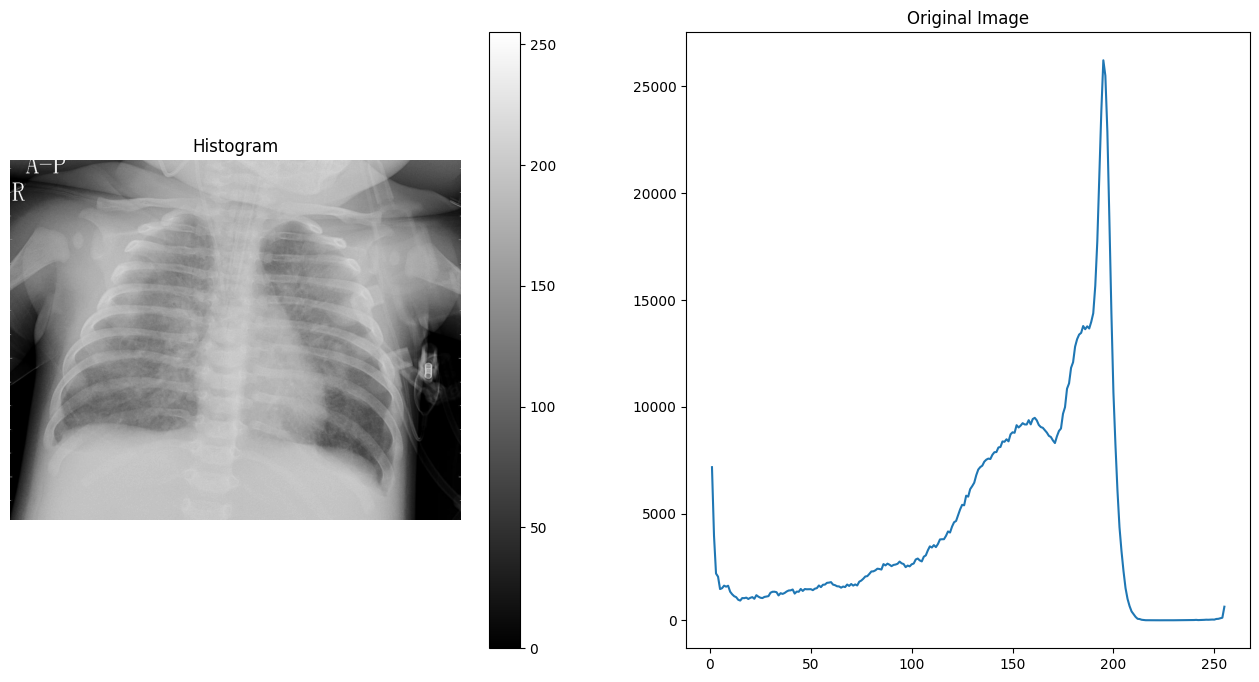

In [ ]:
im = imageio.imread('../dataset/Assigment1/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg')
hist = ndi.histogram(im, 0, 255, 256)
x = np.arange(1, len(hist))

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

im_display = ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[1:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

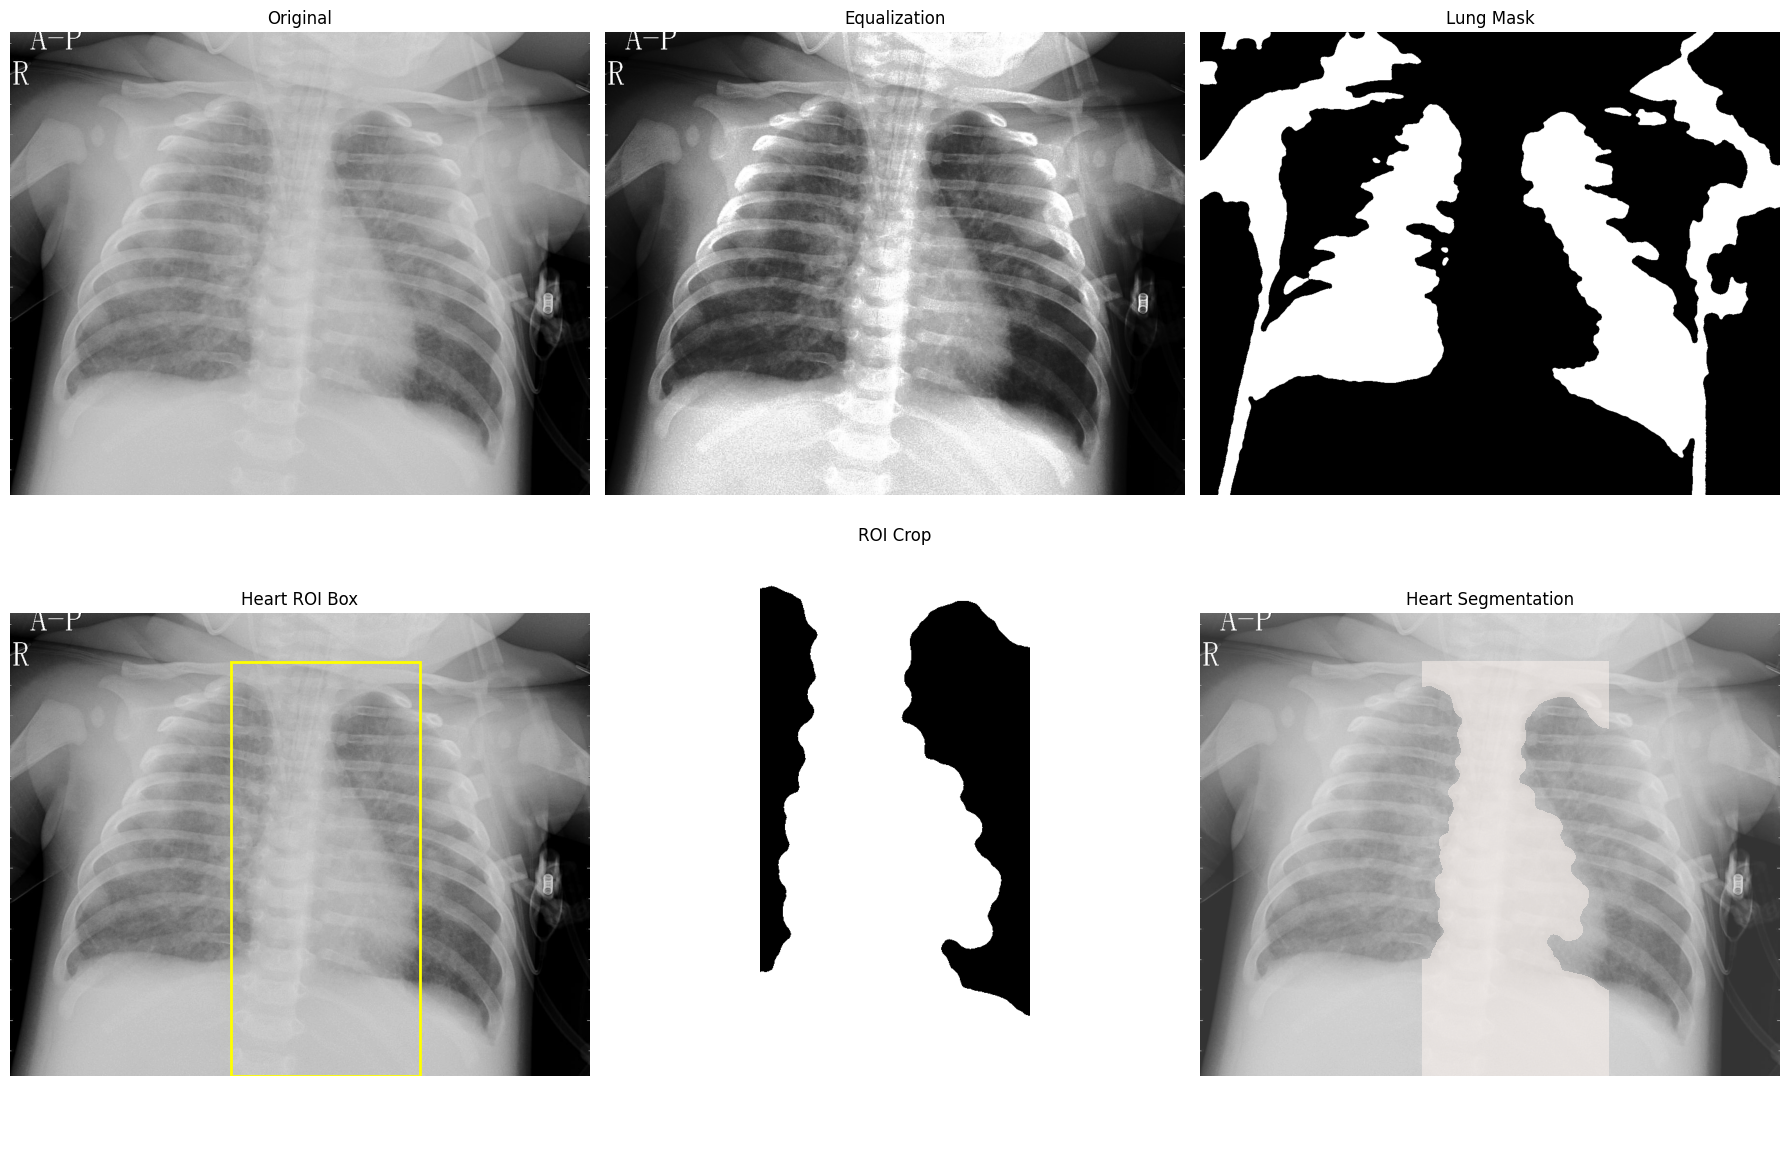

In [ ]:


# ── 1. Enhancement ────────────────────────────────────────────────────────────
# CLAHE only on the image, no aggressive equalization
img_clahe = exposure.equalize_hist(im)
img_filt  = ndi.gaussian_filter(img_clahe, sigma=3)


th_body = filters.threshold_otsu(im)
body = im > th_body
body = morphology.binary_closing(body, morphology.disk(15))
body = ndi.binary_fill_holes(body)

# ── 2. Get Lungs (dark regions) ───────────────────────────────────────────────
th        = filters.threshold_otsu(img_filt)
lung_bin  = (img_filt < th) & body                                      # lungs = dark

lung_bin  = morphology.binary_closing(lung_bin, morphology.disk(5))
lung_bin  = ndi.binary_fill_holes(lung_bin)
lung_bin  = morphology.binary_opening(lung_bin, morphology.disk(3))

lung_mask = lung_bin.copy()

labeled = measure.label(lung_bin)
props = sorted(measure.regionprops(labeled), key=lambda r: r.area, reverse=True)

# ── 3. Define Heart ROI from lung geometry ────────────────────────────────────
lung_props = sorted(props[:2], key=lambda r: r.centroid[1])   # sort left→right
L, R       = lung_props[0].bbox, lung_props[1].bbox
# (min_row, min_col, max_row, max_col)

roi_r0 = max(L[0], R[0])                    # top    of overlap zone
roi_r1 = min(L[2], R[2])                    # bottom of overlap zone
roi_c0 = L[3]                               # right edge of left lung
roi_c1 = R[1]                               # left  edge of right lung

# Expand ROI — heart spills a bit beyond the lung gap
h_pad  = int((roi_c1 - roi_c0) * 0.7)
v_pad  = int((roi_r1 - roi_r0) * 0.01) 
roi_r0 = max(0,          roi_r0 - v_pad) + 100
roi_r1 = min(im.shape[0], roi_r1 + v_pad) 
roi_c0 = max(0,          roi_c0 - h_pad) 
roi_c1 = min(im.shape[1], roi_c1 + h_pad) + 100

# ── 4. Heart Segmentation inside ROI — morphology-based, no ribs ─────────────
roi       = img_filt[roi_r0:roi_r1, roi_c0:roi_c1]

# 4a. Threshold — heart is bright
th_roi    = filters.threshold_otsu(roi)
heart_bin = roi > th_roi

# 4b. Heavy closing to merge fragmented bright blobs (ribs + heart together)
heart_bin = morphology.binary_closing(heart_bin, morphology.disk(21))
heart_bin = ndi.binary_fill_holes(heart_bin)

# 4c. Erode hard — ribs are THIN, heart is THICK
#     After heavy erosion, thin rib blobs disappear, heart survives
heart_bin = morphology.binary_erosion(heart_bin, morphology.disk(8))

# 4d. Dilate back to restore heart size
heart_bin = morphology.binary_dilation(heart_bin, morphology.disk(21))
heart_bin = ndi.binary_fill_holes(heart_bin)

# 4e. Keep only the single largest blob = heart
hl        = measure.label(heart_bin)
hr        = sorted(measure.regionprops(hl), key=lambda r: r.area, reverse=True)
heart_roi = hl == hr[0].label

# Place back onto full canvas
heart_full = np.zeros(im.shape, dtype=bool)
heart_full[roi_r0:roi_r1, roi_c0:roi_c1] = heart_roi

# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

ax[0,0].imshow(im,        cmap='gray'); ax[0,0].set_title('Original');        ax[0,0].axis('off')
ax[0,1].imshow(img_clahe, cmap='gray'); ax[0,1].set_title('Equalization');    ax[0,1].axis('off')
ax[0,2].imshow(lung_mask, cmap='gray'); ax[0,2].set_title('Lung Mask');       ax[0,2].axis('off')

ax[1,0].imshow(im, cmap='gray')
rect = mpatches.Rectangle((roi_c0, roi_r0), roi_c1-roi_c0, roi_r1-roi_r0,
                           lw=2, edgecolor='yellow', facecolor='none')
ax[1,0].add_patch(rect)
ax[1,0].set_title('Heart ROI Box'); ax[1,0].axis('off')

ax[1,1].imshow(heart_roi, cmap='gray');  ax[1,1].set_title('ROI Crop');            ax[1,1].axis('off')

ax[1,2].imshow(im,  cmap='gray', alpha=0.8)
ax[1,2].imshow(np.ma.masked_where(~heart_full, heart_full),
               cmap='Reds', alpha=0.5)
ax[1,2].set_title('Heart Segmentation'); ax[1,2].axis('off')

plt.tight_layout()
plt.show()